In [11]:
import pandas as pd
from data_cleaning import Ausreißer, Skalierung
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.tree import plot_tree

#relevant_data_uncleaned = pd.read_csv('data/relevant_data_uncleaned.csv')


In [10]:

relevant_data_without_outlires = Ausreißer(relevant_data_uncleaned,
                                           default_outlier_strategy = "delete",
                                           except_replace_0=[],
                                           except_replace_mean=[],
                                           except_delete=[],
                                           ignore=[])

#postTransactionAmounts.sharesOwnedFollowingTransaction Korrelation mit amounts.Share
#reportingOwner.relationship.isTenPercentOwner: Varianz = 0.091504, Korrelation mit t_1_percent_change_since_4d = 0.039
#reportingOwner.relationship.isOther: Varianz = 0.061755, Korrelation mit t_1_percent_change_since_4d = 0.041
#USRECD: Varianz = 0.000000
relevant_data_without_outlires_corr_var = relevant_data_without_outlires.drop(columns=['postTransactionAmounts.sharesOwnedFollowingTransaction',
                                                                          'reportingOwner.relationship.isTenPercentOwner',
                                                                          'reportingOwner.relationship.isOther', 
                                                                          'USRECD'])

relevant_data_without_outlires_corr_var_scaled = Skalierung(relevant_data_without_outlires_corr_var,
                   scale_stratagy = 'ausgewählte',
                   variable=['amounts.shares', 'amounts.pricePerShare',
                                    'filing_count_reportingOwner.name',
                                    'trades_14d', 'holding_change_percent'])



amounts.shares wurde mit dem zscore angepasst
amounts.pricePerShare wurde mit dem zscore angepasst
filing_count_reportingOwner.name wurde mit dem zscore angepasst
trades_14d wurde mit dem zscore angepasst
holding_change_percent wurde mit dem zscore angepasst


,dtype,na_count,count,unique,top,freq,mean,std,min,25%,50%,75%,max,skew,var
amounts.shares,float64,0,60187.0,NaN,NaN,NaN,0.0,1.000008,-0.727847,-0.653189,-0.411295,0.205386,3.820359,1.882395,1.000017
direct_ownership,int64,0,60187.0,NaN,NaN,NaN,0.771894,0.419615,0.0,1.0,1.0,1.0,1.0,-1.295967,0.176076
amounts.pricePerShare,float64,0,60187.0,NaN,NaN,NaN,-0.0,1.000008,-1.457319,-0.857366,-0.110759,0.681525,2.878338,0.506850,1.000017
reportingOwner.relationship.isDirector,bool,0,60187,2,True,41470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reportingOwner.relationship.isOfficer,bool,0,60187,2,False,35714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
t_1_percent_change_since_4d,int64,0,60187.0,NaN,NaN,NaN,0.408975,0.491649,0.0,0.0,0.0,1.0,1.0,0.370295,0.241719
t_10_percent_change_since_198d,int64,0,60187.0,NaN,NaN,NaN,0.391829,0.488163,0.0,0.0,0.0,1.0,1.0,0.443191,0.238303
transaction_month,int64,0,60187.0,NaN,NaN,NaN,6.854803,3.334212,1.0,4.0,7.0,10.0,12.0,-0.063332,11.116973
filing_count_reportingOwner.name,float64,0,60187.0,NaN,NaN,NaN,0.0,1.000008,-0.859226,-0.716808,-0.408235,0.351329,3.982996,1.689398,1.000017
high_frequency_trader,int64,0,60187.0,NaN,NaN,NaN,0.339691,0.473608,0.0,0.0,0.0,1.0,1.0,0.676990,0.224305


In [35]:
relevant_data_without_outlires_corr_var_scaled_droped = relevant_data_without_outlires_corr_var_scaled.drop(columns=[
    #'amounts.shares', 
    #'direct_ownership',
    #'amounts.pricePerShare',
    #'reportingOwner.relationship.isDirector',
    #'reportingOwner.relationship.isOfficer',
    't_1_percent_change_since_4d',
    #'t_10_percent_change_since_198d',
    #'transaction_month',
    #'filing_count_reportingOwner.name',
    #'high_frequency_trader',
    #'trades_14d',
    #'high_price',
    #'holding_change_percent',
    #'high_change_in_holdings'
])


                Modell  Accuracy   ROC AUC  Precision    Recall
0        Random Forest  0.660759  0.711619   0.745578  0.210203
1  Logistic Regression  0.602608  0.567475   0.459184  0.051784


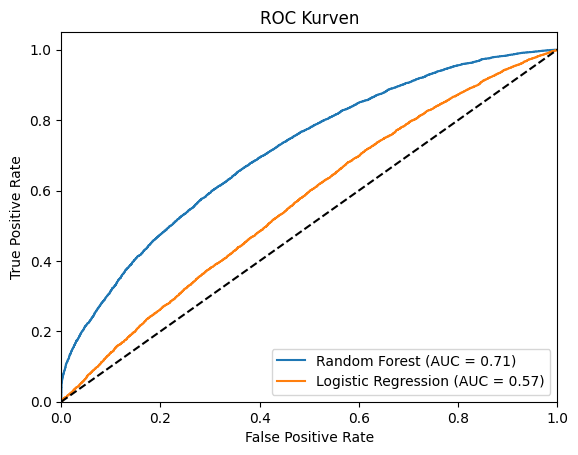

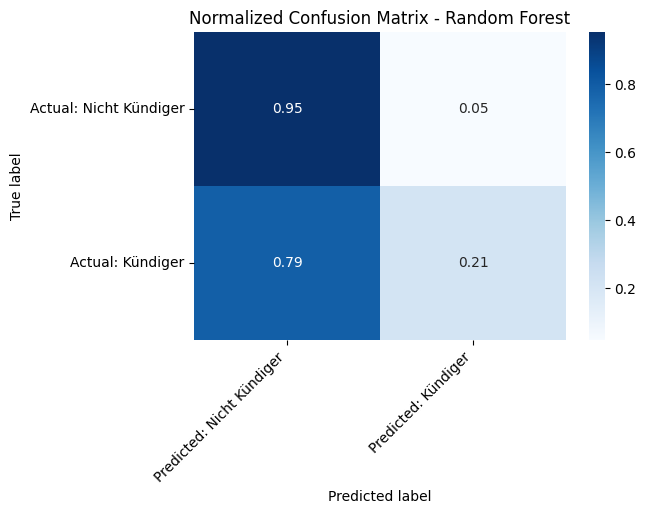

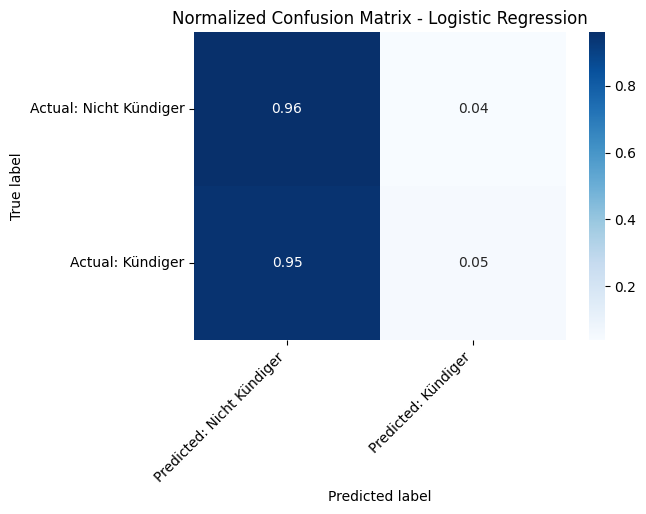

Feature Importance für jedes Modell:
                                        Logistic Regression  Random Forest
high_price                                         0.184665       0.041099
amounts.pricePerShare                              0.128411       0.275644
trades_14d                                         0.067738       0.098310
high_change_in_holdings                            0.062351       0.010610
amounts.shares                                     0.047648       0.114340
filing_count_reportingOwner.name                   0.046909       0.147667
holding_change_percent                             0.044981       0.112683
transaction_month                                  0.043513       0.133764
direct_ownership                                   0.038692       0.017636
reportingOwner.relationship.isDirector             0.026427       0.017316
reportingOwner.relationship.isOfficer              0.023464       0.018860
high_frequency_trader                              0.012080    

In [36]:
df = relevant_data_without_outlires_corr_var_scaled_droped 

## Model training, Logistic Regression und Random Forrest, ROC/AUC, Precision/Recall, feature importance, confusion matrix
# Zielvariable
y = df['t_10_percent_change_since_198d']


# Unabhängige Variablen
x_columns = [col for col in df.columns if col != "t_10_percent_change_since_198d"]

# Daten für unabhängige Variablen
X = df[x_columns]

# Aufteilen in Trainings- und Testdaten, 33 % der Daten für Testset und 67 % für Trainingsset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


# Class-Imbalance berücksichtigen (0/1-Labels vorausgesetzt)
y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1200,
                                            max_depth=10,
                                            max_features="sqrt",
                                            min_samples_split=20,
                                            min_samples_leaf=10,
                                            class_weight=None,
                                            bootstrap=True,
                                            oob_score=True,
                                            n_jobs=-1,
                                            random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=10000),
}

# Dictionary zum Speichern der Ergebnisse
results = []

# Schleife zum Trainieren und Testen der Modelle
for model_name, model in models.items():
    # Modell trainieren
    model.fit(X_train, y_train)
    
    # Vorhersagen auf Testdaten
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für positive Klasse
    
    # Berechnung der Metriken
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # ROC-Kurve berechnen
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    
    # Ergebnis speichern
    results.append({
        "Modell": model_name,
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Precision": precision,
        "Recall": recall
    })
    
    # ROC-Kurve plotten
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Tabelle der Ergebnisse anzeigen
results_df = pd.DataFrame(results)
print(results_df)

# ROC-Kurve visualisieren
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurven')
plt.legend(loc="lower right")
plt.show()

# Loop über alle Modelle
for model_name, model in models.items():
    # Modell trainieren
    model.fit(X_train, y_train)
    
    # Vorhersagen treffen
    y_pred = model.predict(X_test)
    
    # Confusion Matrix berechnen
    cm = confusion_matrix(y_test, y_pred)
    
    # Confusion Matrix in DataFrame umwandeln für besseres Plotting
    df_cm = pd.DataFrame(cm, index=['Actual: Nicht Kündiger', 'Actual: Kündiger'], 
                         columns=['Predicted: Nicht Kündiger', 'Predicted: Kündiger'])
    
    # Konvertiere die Confusion-Matrix-Werte in ein numpy-Array, bevor die Normalisierung durchgeführt wird
    cm_values = df_cm.values.astype('float')  # Numpy-Array erstellen
    cm_normalized = cm_values / cm_values.sum(axis=1)[:, np.newaxis]  # Normalisieren
    
    # Normalisierte Confusion-Matrix zurück in DataFrame umwandeln
    df_cm_normalized = pd.DataFrame(cm_normalized, index=df_cm.index, columns=df_cm.columns)
    
    # Heatmap plotten
    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(df_cm_normalized, annot=True, fmt='.2f', cmap="Blues")
    
    # Achsentitel und Rotationen anpassen
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    
    # Titel und Achsenbeschriftungen hinzufügen
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    
    # Plot anzeigen
    plt.show()
    
# Dictionary für die Speicherung der Feature-Importances
feature_importances = pd.DataFrame()

# Für Logistic Regression werden die Koeffizienten verwendet
if "Logistic Regression" in models:
    log_reg = models["Logistic Regression"] # Hier wird das Logistic-Regression-Modell aus dem models Dictionary extrahiert und der Variablen log_reg zugewiesen. models könnte eine Sammlung von trainierbaren Modellen sein.
    log_reg.fit(X_train, y_train) # Diese Zeile trainiert (fit) das log_reg Modell mit den Trainingsdaten X_train (Features) und y_train (Zielvariable).
    feature_importances["Logistic Regression"] = np.abs(log_reg.coef_[0]) 

# Für Random Forest verwenden wir die Feature Importances
if "Random Forest" in models:
    rf = models["Random Forest"]
    rf.fit(X_train, y_train)
    feature_importances["Random Forest"] = rf.feature_importances_


# Feature-Namen als Index verwenden
feature_importances.index = X_train.columns

# Tabelle der Feature-Wichtigkeiten sortieren und anzeigen
feature_importances = feature_importances.sort_values(by="Logistic Regression", ascending=False)
print("Feature Importance für jedes Modell:")
print(feature_importances)


In [ ]:

## Odds Ratio & % Wahrscheinlicher Kündiger/nicht-Kündiger Tabelle

# Odds-Ratio-Tabelle mit Richtung und %-Effekt
log_reg = models["Logistic Regression"].fit(X_train, y_train)
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
or_ = np.exp(coefs)

or_table = pd.DataFrame({
    "Koeffizient": coefs,
    "Odds Ratio": or_,
})

# Prozent-Effekt auf die Odds (nicht direkt Wahrscheinlichkeit!)
or_table["% Wahrscheinlicher Kündiger/nicht-Kündiger"] = np.where(
    or_table["Odds Ratio"]>=1,
    (or_table["Odds Ratio"]-1)*100,
    -(1-or_table["Odds Ratio"])*100
).round(1)

or_table = or_table.reindex(or_table["Koeffizient"].abs().sort_values(ascending=False).index)
or_table



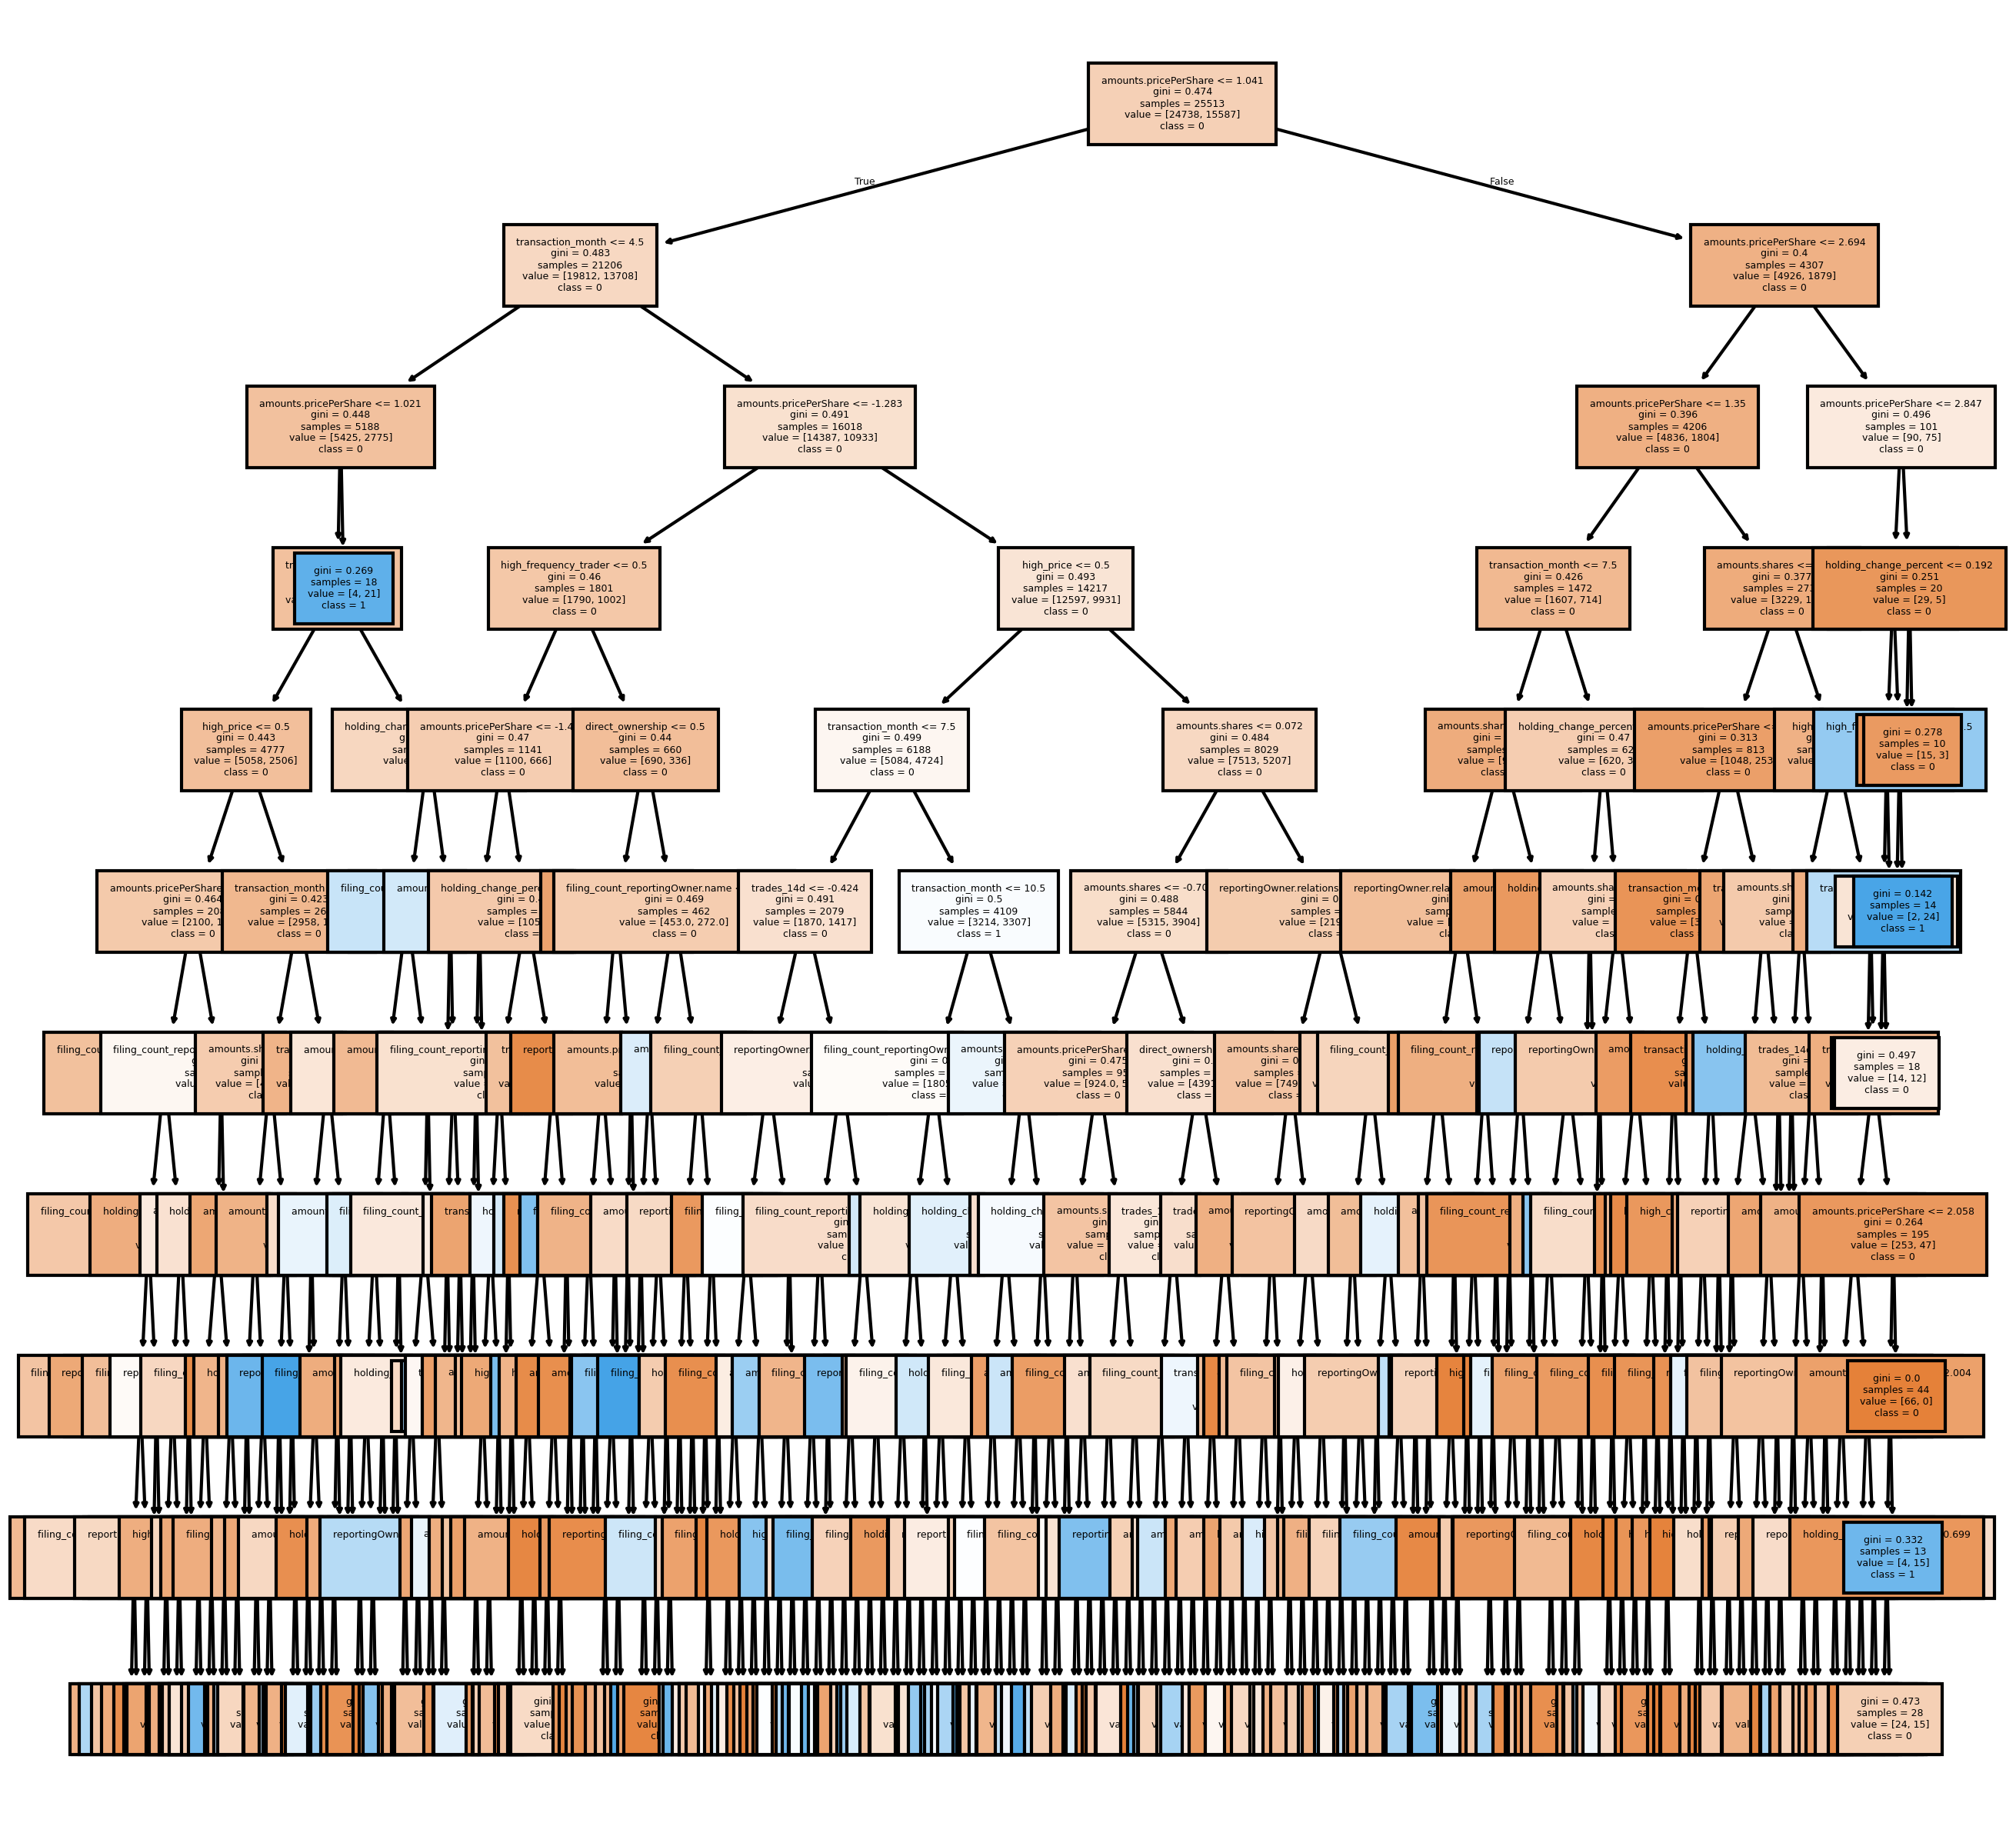

In [ ]:


## Random Forrest Tree plotten
# Zielvariable
y = df['t_10_percent_change_since_198d']


# Unabhängige Variablen
x_columns = [col for col in df.columns if col != "t_10_percent_change_since_198d"]

# Daten für unabhängige Variablen
X = df[x_columns]

# Aufteilen in Trainings- und Testdaten, 33 % der Daten für Testset und 67 % für Trainingsset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


# Class-Imbalance berücksichtigen (0/1-Labels vorausgesetzt)
y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1200,
                                            max_depth=10,
                                            max_features="sqrt",
                                            min_samples_split=20,
                                            min_samples_leaf=10,
                                            class_weight=None,
                                            bootstrap=True,
                                            oob_score=True,
                                            n_jobs=-1,
                                            random_state=42),
}

# Dictionary zum Speichern der Ergebnisse
results = []

# Schleife zum Trainieren und Testen der Modelle
for model_name, model in models.items():
    # Modell trainieren
    model.fit(X_train, y_train)
    
    # Vorhersagen auf Testdaten
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für positive Klasse

fig, ax = plt.subplots(figsize=(10,10),dpi=300,)
fn = list(X_train.columns) # feature names
cn = [str(cls) for cls in np.unique(y_train)] #classnames

estimator = model.estimators_[0]

plot_tree(estimator,
feature_names=fn,
class_names=cn,
filled=True,
fontsize=3,
ax=ax)

#fig.savefig("baum_plot.png", dpi=300, bbox_inches='tight')

plt.show()

